Here, I am attempting to predict the next day's percentage change.

In [2]:
import pandas as pd

# Import dataset
# Prepare dataset

df_model = pd.read_csv(
    'transformed_daily_data/daily_data_5y_30k_features1.csv'
)

# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort dataset
df_model = df_model.sort_values(
    ['ticker', 'timestamp']
).copy()




In [4]:
# Create target (next day closing price)
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()


# Next close change
df_model['next_close_change'] = df_model['next_close'] - df_model['close']


# Next close change PCT
df_model['next_close_change_pct'] = (
    (df_model['next_close'] - df_model['close']) / df_model['close']
) * 100


df_model

,timestamp,ticker,open,high,low,close,volume,vwap,transactions,close_vs_open_pct,...,MACD,MACD_signal,MACD_hist,rolling_volatility,close_lag1,close_lag2,return_lag1,next_close,next_close_change,next_close_change_pct
0,2021-07-15,AA,35.27,35.9300,34.2350,34.54,8.679014e+06,34.9029,59127.0,-0.020697,...,-0.409851,-0.364569,-0.045282,0.038311,35.14,35.62,-0.013476,32.95,-1.59,-4.603358
1,2021-07-16,AA,35.35,35.7000,32.7323,32.95,1.478064e+07,33.4495,91473.0,-0.067893,...,-0.620150,-0.415686,-0.204464,0.019171,34.54,35.14,-0.017075,31.62,-1.33,-4.036419
2,2021-07-19,AA,31.99,32.4500,30.9950,31.62,1.240088e+07,31.6877,83015.0,-0.011566,...,-0.883943,-0.509337,-0.374606,0.015777,32.95,34.54,-0.046034,34.95,3.33,10.531309
3,2021-07-20,AA,31.55,35.2602,31.2600,34.95,1.578655e+07,34.1895,99391.0,0.107765,...,-0.814904,-0.570450,-0.244454,0.061817,31.62,32.95,-0.040364,37.09,2.14,6.123033
4,2021-07-21,AA,35.25,37.4100,35.2500,37.09,1.200015e+07,36.7297,74959.0,0.052199,...,-0.580815,-0.572523,-0.008292,0.067239,34.95,31.62,0.105313,37.23,0.14,0.377460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478378,2026-04-23,ZTS,117.19,117.5999,114.9500,116.06,4.532932e+06,116.0779,57313.0,-0.009642,...,-0.336494,-0.314996,-0.021497,0.023624,117.52,118.18,-0.005585,116.87,0.81,0.697915
478379,2026-04-24,ZTS,116.01,117.0500,115.4100,116.87,4.185102e+06,116.4944,52997.0,0.007413,...,-0.474241,-0.346845,-0.127396,0.017329,116.06,117.52,-0.012423,117.87,1.00,0.855652
478380,2026-04-27,ZTS,116.62,119.6800,116.6000,117.87,3.160355e+06,118.2275,43149.0,0.010719,...,-0.496987,-0.376874,-0.120113,0.018470,116.87,116.06,0.006979,116.65,-1.22,-1.035039
478381,2026-04-28,ZTS,117.23,118.2900,116.0750,116.65,2.972547e+06,117.0538,47388.0,-0.004948,...,-0.606465,-0.422792,-0.183673,0.009769,117.87,116.87,0.008557,113.83,-2.82,-2.417488


In [6]:
%%time

# Import libraries
import os
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import (
    train_test_split,
    TimeSeriesSplit,
    GridSearchCV,
    cross_val_score,
    KFold
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score
)


# Load dataset
df_model = pd.read_csv(
    'transformed_daily_data/daily_data_5y_30k_features1.csv'
)

# Prepare dataset

# Ensure datetime formatting
df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])

# Sort dataset
df_model = df_model.sort_values(
    ['ticker', 'timestamp']
).copy()


# Next day closing price
df_model['next_close'] = (
    df_model.groupby('ticker')['close'].shift(-1)
)

# Remove final row per ticker for which next_close does not exist
df_model = df_model[
    df_model['next_close'].notna()
].copy()


# Next close change
df_model['next_close_change'] = df_model['next_close'] - df_model['close']


# Next close change PCT - This will be the target
df_model['next_close_change_pct'] = (
    (df_model['next_close'] - df_model['close']) / df_model['close']
) * 100



# Target already created with dataset loading


# Remove final row per ticker for which next_close does not exist)
df_model = df_model[
    df_model['next_close'].notna()
].copy()



# Train/test split

# Train on 2021-2024 data
train_df = df_model[
    (df_model['timestamp'] >= '2021-01-01') &
    (df_model['timestamp'] < '2025-01-01')
].copy()

# Test on 2025 data
test_df = df_model[
    (df_model['timestamp'] >= '2025-01-01') &
    (df_model['timestamp'] < '2026-01-01')
].copy()


# Select features
exclude_cols = [
    'timestamp',
    'ticker',
    'next_close_change_pct'
]

feature_cols = [
    col for col in df_model.columns
    if col not in exclude_cols
]


X_train = train_df[feature_cols]
y_train = train_df['next_close_change_pct']

X_test = test_df[feature_cols]
y_test = test_df['next_close_change_pct']


# Define model
model = RandomForestRegressor(
    n_estimators=200,
    max_features=1,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


# Train model
model.fit(X_train, y_train)


# Get predictinos
y_test_pred = model.predict(X_test)


# Define evaluation metrics
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
medae = median_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

# Print evaluation metrics
print("\n===== REGRESSION METRICS =====")

print(f"MAE:    {mae:.4f}")
print(f"MSE:    {mse:.4f}")
print(f"RMSE:   {rmse:.4f}")
print(f"MedAE:  {medae:.4f}")
print(f"R²:     {r2:.4f}")


===== REGRESSION METRICS =====
MAE:    0.7183
MSE:    3.4826
RMSE:   1.8662
MedAE:  0.3821
R²:     0.6627
CPU times: user 6min 51s, sys: 12.8 s, total: 7min 4s
Wall time: 1min 48s


In [7]:
results_df = test_df.copy()
results_df['pred_next_close_change_pct'] = (y_test_pred).round(2)
results_df['pred_error'] = results_df['pred_next_close_change_pct'] - results_df['next_close_change_pct']
results_df['abs_pred_error'] = results_df['pred_error'].abs()

In [10]:
daily_prediction_summary = (
    results_df
    .groupby('timestamp')
    .agg(
        stocks_predicted=('ticker', 'count'),

        actual_next_close_pct_change_mean=('next_close_change_pct', 'mean'),
        predicted_next_close_pct_change_mean=('pred_next_close_change_pct', 'mean'),

        pred_error_mean=('pred_error', 'mean'),
        pred_error_median=('pred_error', 'median'),

        abs_pred_error_mean=('abs_pred_error', 'mean'),
        abs_pred_error_median=('abs_pred_error', 'median'),

        pred_error_std=('pred_error', 'std'),

        max_overprediction=('pred_error', 'max'),
        max_underprediction=('pred_error', 'min')
    )
    .reset_index()
)

daily_prediction_summary

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction
0,2025-01-02,397,1.421792,1.049018,-0.372774,-0.183062,0.687293,0.360357,1.333198,7.294694,-10.123231
1,2025-01-03,397,1.280758,0.514030,-0.766728,0.014969,1.191826,0.355433,11.978762,1.868571,-237.648889
2,2025-01-06,397,-0.608645,-0.438161,0.170483,0.057475,0.566862,0.348946,1.051112,9.464862,-6.101398
3,2025-01-07,397,-0.444311,-0.325894,0.118417,-0.006701,0.596127,0.372575,1.139312,8.711126,-7.125348
4,2025-01-08,397,-1.548944,-1.181688,0.367257,0.280555,0.668169,0.435969,1.031021,8.621024,-4.363582
...,...,...,...,...,...,...,...,...,...,...,...
245,2025-12-24,397,-0.095907,-0.035491,0.060415,0.008624,0.393127,0.327045,0.601677,6.218373,-2.907368
246,2025-12-26,397,-0.484840,-0.419849,0.064991,0.011637,0.376971,0.285405,0.540187,3.438904,-1.649744
247,2025-12-29,397,-0.153850,-0.203275,-0.049425,-0.077288,0.356986,0.302122,0.482252,2.292490,-3.601381
248,2025-12-30,397,-0.857997,-0.887305,-0.029308,-0.040345,0.297752,0.198520,0.479291,3.784509,-3.405072


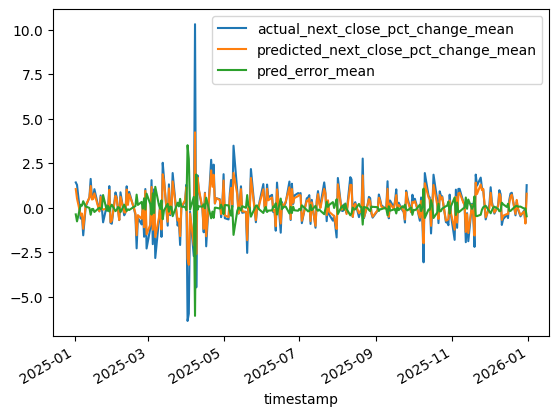

In [15]:
daily_prediction_summary.set_index('timestamp')[['actual_next_close_pct_change_mean', 'predicted_next_close_pct_change_mean', 'pred_error_mean']].plot()
plt.show()

In [13]:
daily_prediction_summary.nlargest(10, 'abs_pred_error_mean')

,timestamp,stocks_predicted,actual_next_close_pct_change_mean,predicted_next_close_pct_change_mean,pred_error_mean,pred_error_median,abs_pred_error_mean,abs_pred_error_median,pred_error_std,max_overprediction,max_underprediction
65,2025-04-08,397,10.308052,4.235164,-6.072889,-5.158493,6.108197,5.158493,4.535235,1.146855,-21.177302
61,2025-04-02,397,-6.358696,-2.845869,3.512827,2.891739,3.717622,2.916680,3.735422,18.827035,-5.552456
62,2025-04-03,397,-5.948873,-3.205340,2.743533,2.413579,2.964079,2.439937,2.515686,15.800588,-6.037014
66,2025-04-09,397,-4.474491,-2.608287,1.866204,1.176510,2.106350,1.270054,2.486576,15.146585,-1.653223
87,2025-05-09,397,3.485017,1.960353,-1.524664,-1.001562,1.900318,1.280104,2.427656,9.483774,-21.253023
43,2025-03-07,397,-2.825034,-1.649295,1.175740,0.575270,1.409876,0.718242,2.092552,12.406454,-1.448756
14,2025-01-24,397,-0.819347,-0.107204,0.712143,-0.085098,1.295534,0.466704,3.093122,24.029716,-2.590017
64,2025-04-07,397,-2.717120,-2.109244,0.607875,0.279385,1.288317,0.831812,1.995543,16.222522,-6.954515
192,2025-10-09,397,-3.064548,-1.993401,1.071147,0.625560,1.203988,0.663074,1.467955,11.245238,-3.879069
1,2025-01-03,397,1.280758,0.514030,-0.766728,0.014969,1.191826,0.355433,11.978762,1.868571,-237.648889
